In [1]:
import importlib
import utils
importlib.reload(utils)

import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

# Introduction
This notebook measures the time taken to
- generate the laplacian and time-step operator(s)
- generate the MPS of an input function
- generate the MPO of the time-step operator(s)
- evolve the input function by a specified number of `steps` via repeated multiplication with the time-step operator(s)
- evolve the MPS of the input function by a specified number of `steps` via repeated contractions with the time-step MPO(s)

for a list of specified values of `n`, where grid size `N = 2**n`.

The limiting constraint appears to be the size of the dense Laplacian matrix. For the LPE2 time evolution scheme where two complex time-step operators are required, my laptop crashes at `n=15`. Furthermore, if one uses `evolve_mps_timed()` instead of `evolve_mps()`, we can see that the highest bond dimension achieved by the MPS is only 8.

# Parameters

In [2]:
ns = [6, 8, 10, 11, 12, 13, 14]  # values of n to iterate over, where grid size N = 2**n
steps = 200                      # number of steps required for time evolution
nu = 1e-3                        # diffusion coefficient 
cfl = 0.1                        # controls time step relative to grid spacing. affects stability of time-step scheme

def u(x):                        # our initial function
    return np.sin(2*np.pi*2*x) + 0.5*np.sin(2*np.pi*7*x)

# Experiment

In [3]:
times_op     = []   # time taken to initialise laplacian and time-step operator(s)
times_mps    = []   # time taken to convert initial function u0 to MPS
times_mpo    = []   # time taken to convert time-step operator(s) to MPO(s)
times_ev_op  = []   # time taken to evolve the u0 via repeated multiplication of time-step operator(s)
times_ev_mps = []   # time taken to evolve the MPS representation of u0 via repeated contractions with MPO of time-step operator(s) 

for n in ns:
    N  = 2**n
    x  = np.linspace(0, 1, N, endpoint=False)
    dx = x[1] - x[0] 
    dt = utils.delta_t(cfl, dx, nu)
    u0 = u(x)
    
    t = time.perf_counter()
    L = utils.laplacian(N, dx, "periodic", "dense")
    A = utils.time_step(L, 2, dt, nu)
    t_op = time.perf_counter() - t

    t = time.perf_counter()
    mps0 = utils.vec_to_qtt_mps(u0, n)
    t_mps = time.perf_counter() - t

    t = time.perf_counter()
    mpoA = utils.mats_to_qtt_mpos(A, n)
    t_mpo = time.perf_counter() - t

    t = time.perf_counter()
    times, us, norms = utils.evolve_operator(u0, steps, A, dt)
    t_evolve_op = time.perf_counter() - t

    t = time.perf_counter()
    mps_saved, bond_track = utils.evolve_mps(mps0, mpoA, steps)
    # mps_saved, bond_track = utils.evolve_mps_timed(mps0, mpoA, steps)   # in case you want to see the time taken and max bond dim for each step
    t_evolve_mps = time.perf_counter() - t


    times_op.append(t_op)
    times_mps.append(t_mps)
    times_mpo.append(t_mpo)
    times_ev_op.append(t_evolve_op)
    times_ev_mps.append(t_evolve_mps)


Timing comparison (evolution over 200 time steps)

 n  N = 2^n  setup (Op)  setup (MPS)  setup (MPO)  setup (TN total)  evol (Op)  evol (TN)  speedup (evol)
 6       64     0.00034      0.00573      0.00767           0.01340    0.00346    0.50959         0.00680
 8      256     0.00077      0.00031      0.01187           0.01219    0.00998    0.59191         0.01686
10     1024     0.01862      0.00054      0.19458           0.19512    0.15890    0.69705         0.22796
11     2048     0.08131      0.00080      0.78689           0.78769    0.51868    0.67649         0.76672
12     4096     0.40593      0.00095      3.51453           3.51548    1.59319    0.74454         2.13984
13     8192     2.77911      0.00517     15.14454          15.14971    6.49447    0.96389         6.73774
14    16384    12.73367      0.00577    142.77800         142.78377  302.10886    0.93145       324.34286


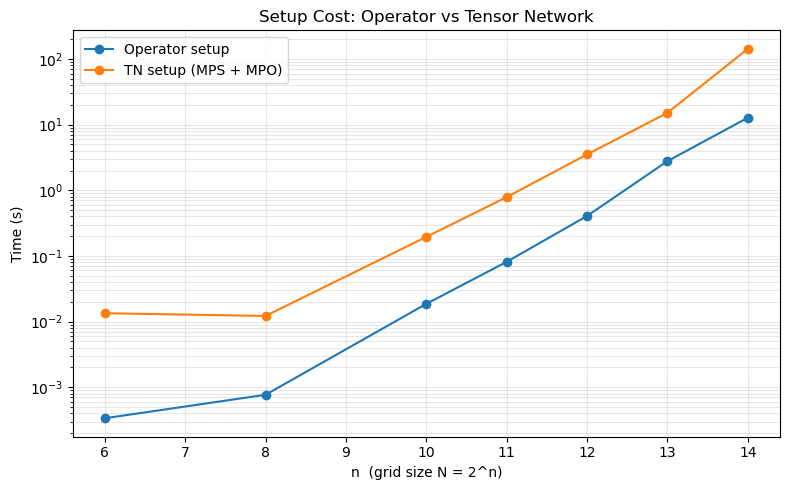

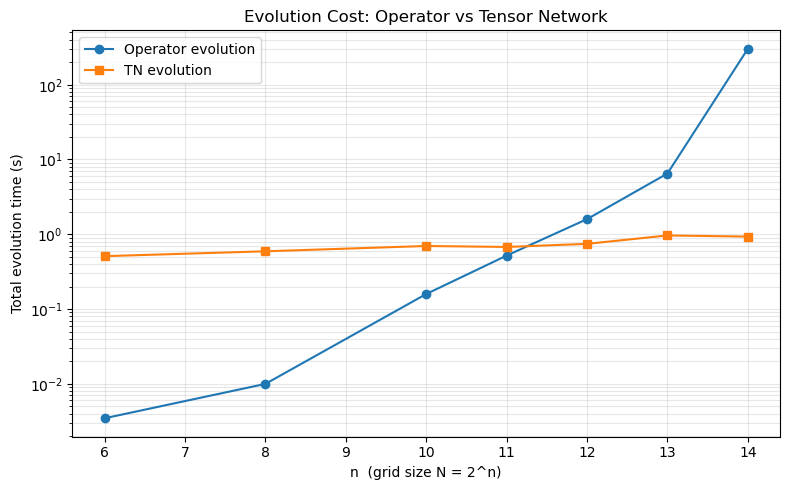

In [9]:
# ======================
# RAW NUMBERS COMPARISON
# ======================

N_vals = [2**n for n in ns]

print(f"Timing comparison (evolution over {steps} time steps)\n")
df = pd.DataFrame({
    "n": ns,
    "N = 2^n": N_vals,
    "setup (Op)": times_op,
    "setup (MPS)": times_mps,
    "setup (MPO)": times_mpo,
    "setup (TN total)": [m + p for m, p in zip(times_mps, times_mpo)],
    "evol (Op)": times_ev_op,
    "evol (TN)": times_ev_mps,
})
df["speedup (evol)"] = df["evol (Op)"] / df["evol (TN)"]
df = df.round(5)
print(df.to_string(index=False))



# ==============================
# INITIALISATION TIME COMPARISON
# ==============================

times_tn_setup = [m + p for m, p in zip(times_mps, times_mpo)]

plt.figure(figsize=(8,5))
plt.plot(ns, times_op, "o-", label="Operator setup")
plt.plot(ns, times_tn_setup, "o-", label="TN setup (MPS + MPO)")
plt.yscale("log")
plt.xlabel("n  (grid size N = 2^n)")
plt.ylabel("Time (s)")
plt.title("Setup Cost: Operator vs Tensor Network")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()



# =========================
# TIME EVOLUTION COMPARISON
# =========================

plt.figure(figsize=(8,5))

plt.plot(ns, times_ev_op, "o-", label="Operator evolution")
plt.plot(ns, times_ev_mps, "s-", label="TN evolution")

plt.yscale("log")
plt.xlabel("n  (grid size N = 2^n)")
plt.ylabel("Total evolution time (s)")
plt.title("Evolution Cost: Operator vs Tensor Network")

plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()